---

---
## Tarefa 3.5 - Análise Exploratória e Estatística Descritiva - Visualização Gráfica

Esta tarefa consiste em explorar por meio de métodos de descrição gráfica (visualização de dados) o conjunto de dados *Hourly Wages*.

Você deve implementar em Python e responder os itens solicitados abaixo utilizando a biblioteca [Matplotlib](https://matplotlib.org/) e/ou [Seaborn](https://seaborn.pydata.org/) e outras que desejar ou forem necessárias.

Exemplos dos gráficos solicitados estão nos links das bibliotecas acima e também no notebook [Visualização_gráfica.ipynb](https://colab.research.google.com/github/malegopc/DSBD/blob/main/Notebooks/Visualização_gráfica.ipynb).

---



---



## Conjunto de dados *Hourly Wages*

Esse conjunto de dados é popularmente empregado para a tarefa de regressão em Machine Learning. Constrói-se e ajusta-se um modelo de aprendizado de máquina para predizer/estimar o salário de um funcionário em função de suas características (anos de estudos, experiência de trabalho, filiação sindical, região, ocupação e sexo).

- Número de Instâncias: 534

- Número de Atributos: 9 atributos numéricos e o target (*wage_per_hour*)

- Informações dos Atributos:
  - union (filiação sindical)
  - education_yrs (anos de instrução)
  - experience_yrs (anos de experiência)
  - age (idade)
  - female (sexo)
  - marr (estado civil - casado)
  - south (região)
  - manufacturing (indústria)
  - construction (construção)

  
- Variável de destino (target): wage_per_hour



## Implementar os itens abaixo:

#### a-) Clonar o repositório de dados da disciplina (DSBD) hospedado no GitHUb.
*Obs: Você pode ignorar este item caso realize a tarefa no Jupyter Notebook. O conjunto de dados Hourly Wages pode ser baixado [clicando aqui](https://raw.githubusercontent.com/malegopc/DSBD/main/Datasets/Hourly_wages/hourly_wages.csv)*.


In [1]:
import requests

url = "https://raw.githubusercontent.com/malegopc/DSBD/main/Datasets/Hourly_wages/hourly_wages.csv"
response = requests.get(url)

with open("hourly_wages.csv", "wb") as f:
    f.write(response.content)

print("Dataset 'hourly_wages.csv' baixado com sucesso!")

Dataset 'hourly_wages.csv' baixado com sucesso!


#### b-) Ler o dataset "*Hourly_wages/hourly_wages.csv*" como dataframe utilizando a biblioteca Pandas e mostrar as 5 primeiras e 5 últimas linhas.

In [2]:
import pandas as pd

df = pd.read_csv('hourly_wages.csv')
print('Primeiras 5 linhas:')
print(df.head())
print('\nÚltimas 5 linhas:')
print(df.tail())

Primeiras 5 linhas:
   wage_per_hour  union  education_yrs  experience_yrs  age  female  marr  \
0           5.10      0              8              21   35       1     1   
1           4.95      0              9              42   57       1     1   
2           6.67      0             12               1   19       0     0   
3           4.00      0             12               4   22       0     0   
4           7.50      0             12              17   35       0     1   

   south  manufacturing  construction  
0      0              1             0  
1      0              1             0  
2      0              1             0  
3      0              0             0  
4      0              0             0  

Últimas 5 linhas:
     wage_per_hour  union  education_yrs  experience_yrs  age  female  marr  \
529          11.36      0             18               5   29       0     0   
530           6.10      0             12              33   51       1     1   
531          23.25   

#### c-) Mostrar os histogramas dos atributos: *education_yrs*, *experience_yrs* e *age* num mesmo quadro de plotagem (usando *subplots*).

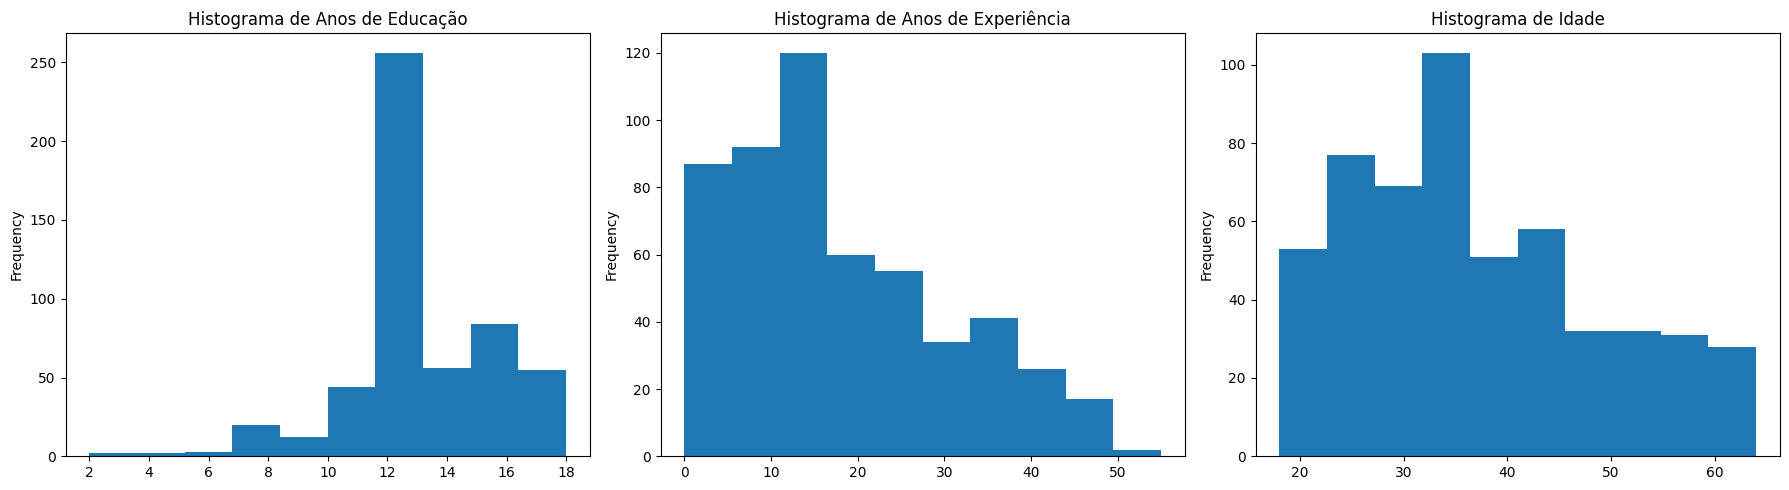

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df['education_yrs'].plot(kind='hist', ax=axes[0], title='Histograma de Anos de Educação')
df['experience_yrs'].plot(kind='hist', ax=axes[1], title='Histograma de Anos de Experiência')
df['age'].plot(kind='hist', ax=axes[2], title='Histograma de Idade')

plt.tight_layout()
plt.show()

#### d-) Mostrar os gráficos de setores (*pie chart*) de cada um dos atributos: *union*, *female*, *marr*, *south*, *manufacturing* e *construction* num mesmo quadro de plotagem (usando subplots).

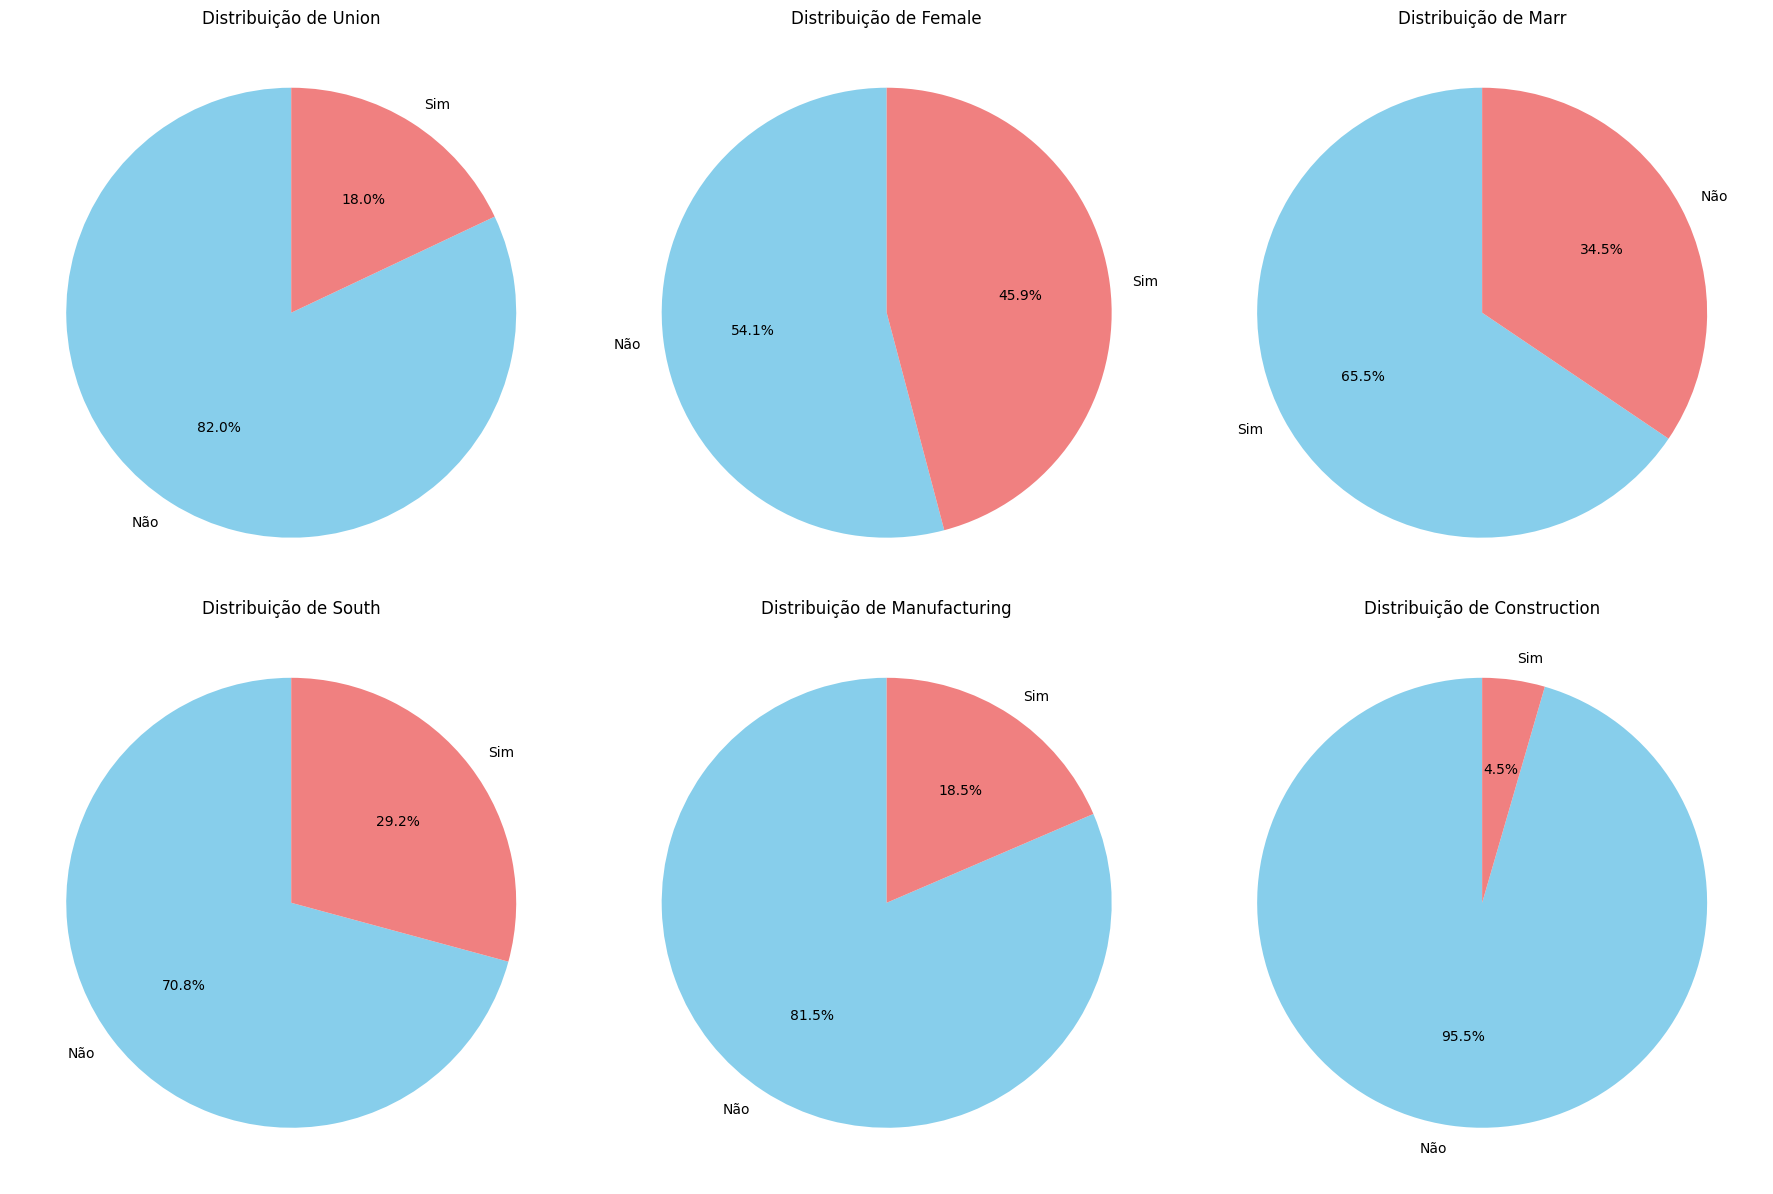

In [4]:
import matplotlib.pyplot as plt

categorical_cols = ['union', 'female', 'marr', 'south', 'manufacturing', 'construction']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten() # Flatten the 2x3 array of axes for easy iteration

for i, col in enumerate(categorical_cols):
    counts = df[col].value_counts()
    labels = ['Não' if idx == 0 else 'Sim' for idx in counts.index] # Assuming 0=No, 1=Yes based on dataset description
    axes[i].pie(counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
    axes[i].set_title(f'Distribuição de {col.replace("_", " ").title()}')

plt.tight_layout()
plt.show()

#### e-) Mostrar os boxplots das variáveis *education_yrs*, *experience_yrs* e *age* num mesmo quadro de plotagem (usando *subplots*).

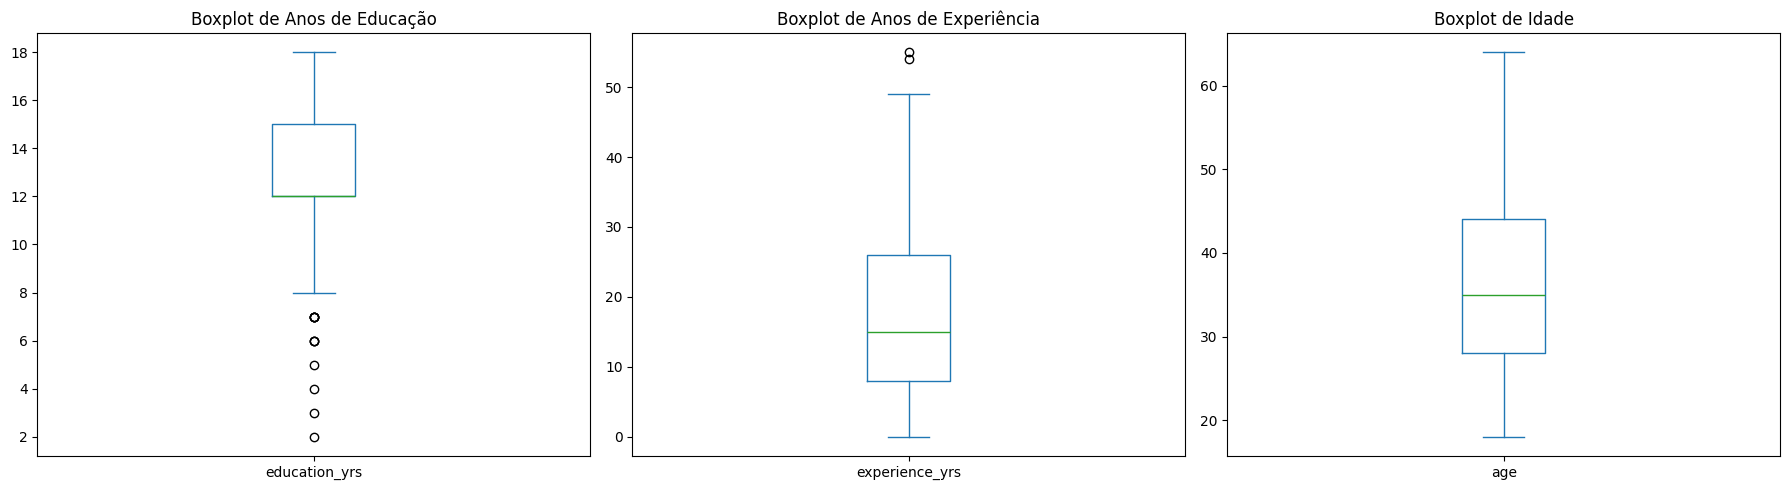

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df['education_yrs'].plot(kind='box', ax=axes[0], title='Boxplot de Anos de Educação')
df['experience_yrs'].plot(kind='box', ax=axes[1], title='Boxplot de Anos de Experiência')
df['age'].plot(kind='box', ax=axes[2], title='Boxplot de Idade')

plt.tight_layout()
plt.show()

#### f-) Mostre lado a lado os boxplots da variável *age* discriminados por sexo (female).

/tmp/ipykernel_578/3220110147.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='female', y='age', data=df, palette={'0': 'skyblue', '1': 'lightcoral'})


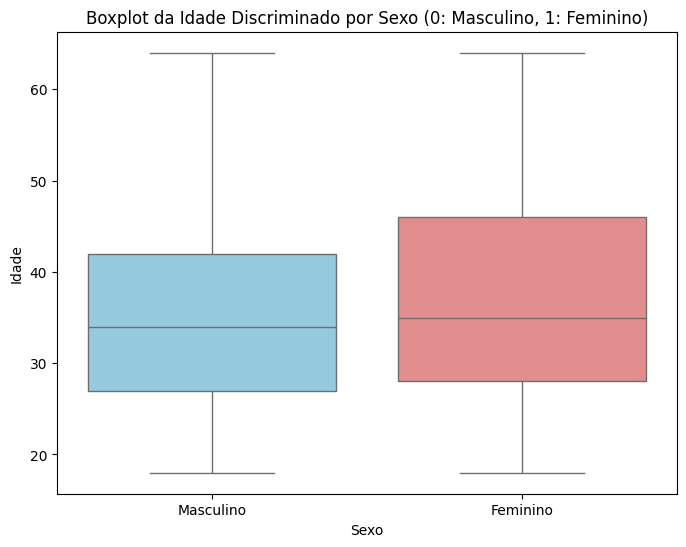

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.boxplot(x='female', y='age', data=df, palette={'0': 'skyblue', '1': 'lightcoral'})
plt.title('Boxplot da Idade Discriminado por Sexo (0: Masculino, 1: Feminino)')
plt.xlabel('Sexo')
plt.ylabel('Idade')
plt.xticks(ticks=[0, 1], labels=['Masculino', 'Feminino'])
plt.show()

#### g-) Responda observando os boxplots construídos no item anterior:

i-) Qual sexo apresenta maior variabilidade (dispersão) de idade? Resposta: Masculino

ii-) Qual é aproximadamente o 2o. quartil das idades das mulheres? Resposta: 33 anos

iii-) Qual é aproximadamente o 1o. quartil das idades dos homens? Resposta: 29 anos

#### h-) Mostre lado a lado os boxplots da variável *wage_per_hour* discriminados por sexo (female).

/tmp/ipykernel_578/3592238211.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='female', y='wage_per_hour', data=df, palette={'0': 'skyblue', '1': 'lightcoral'})


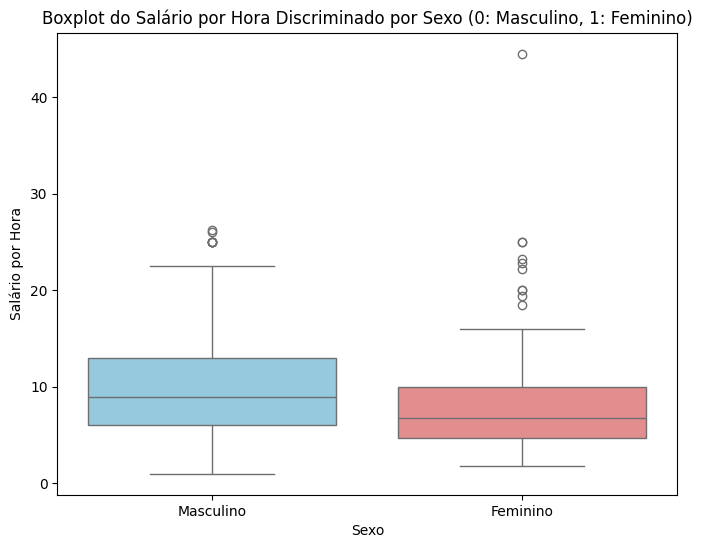

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.boxplot(x='female', y='wage_per_hour', data=df, palette={'0': 'skyblue', '1': 'lightcoral'})
plt.title('Boxplot do Salário por Hora Discriminado por Sexo (0: Masculino, 1: Feminino)')
plt.xlabel('Sexo')
plt.ylabel('Salário por Hora')
plt.xticks(ticks=[0, 1], labels=['Masculino', 'Feminino'])
plt.show()

#### i-) Análise comparativamente os boxplots do item anterior e comente as informações que podem ser exploradas a respeito dos salários por hora de homens e mulheres. Quais conclusões podemos obter?

Resposta: O boxplot mostra que o salário por hora dos homenstem uma mediana e um intervalo interquartil maiores em comparação com o das mulheres. Isso sugere que os homens, em média, recebem salários por hora mais altos e com maior variabilidade do que as mulheres. Há também a presença de outliers com salários significativamente mais altos na categoria masculina.

#### j-) Mostre lado a lado os boxplots da variável wage_per_hour discriminados por estado civil (marr).

/tmp/ipykernel_578/1201147709.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='marr', y='wage_per_hour', data=df, palette={'0': 'lightgreen', '1': 'gold'})


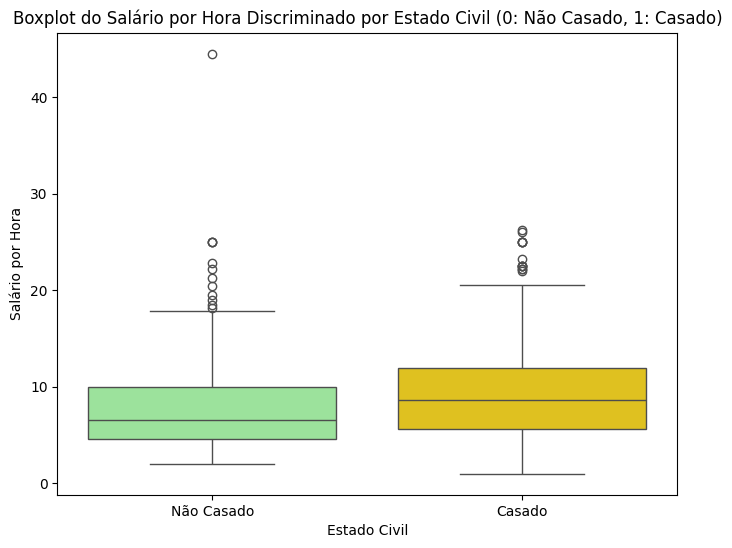

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.boxplot(x='marr', y='wage_per_hour', data=df, palette={'0': 'lightgreen', '1': 'gold'})
plt.title('Boxplot do Salário por Hora Discriminado por Estado Civil (0: Não Casado, 1: Casado)')
plt.xlabel('Estado Civil')
plt.ylabel('Salário por Hora')
plt.xticks(ticks=[0, 1], labels=['Não Casado', 'Casado'])
plt.show()

#### k-) Análise comparativamente os boxplots do item anterior e comente as informações que podem ser exploradas a respeito dos salários por hora de casados e não casados. Quais conclusões podemos obter?

Resposta: O boxplot indica que pessoas casadas tendem a ter um salário por hora mediano mais alto e uma maior dispersão  nos salários em comparação com as pessoas não casadas. Isso pode sugerir que o estado civil está associado a salários por hora potencialmente mais altos e com maior variabilidade.